In [2]:
import os, sys
%pylab inline
plt.style.use('default')
import pandas as pd

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [157]:
# Google sheet with the data
spreadsheet_id = "1rF6KRdGkyQq3VtTHx7fhZoprIboU4AooWy5Jqx5fbeg"
SHEET_URL = lambda gid: f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={gid}"

# Sechellia Analysis

## Load the data

### Load the MS-GC data from its tab.

In [137]:
noni_data_gid = 365555364
noni_url = SHEET_URL(noni_data_gid)
df = pd.read_csv(noni_url)
df = df.set_index('Odour')
column_tuples = [col.split('_rep') for col in df.columns]
df.columns = pd.MultiIndex.from_tuples(column_tuples, names=['Sample', 'Replicate'])
df.head()

Sample                          S1                                      \
Replicate                        1        2        3        4        5   
Odour                                                                    
1-Butanol                    22608    16326    13068    12336        0   
Acetoin                      45918    14022    27243    18343    15871   
3-Buten-1-ol, 3-methyl-    2580259  2158629  2357474  2259012  2103779   
2-Buten-1-ol, 3-methyl-     674520   630612   732131   718104   658692   
Butanoic acid              5874729  4386522  4633598  4017837  4495302   

Sample                         S3                                 ...  \
Replicate                       1       2       3       4      5  ...   
Odour                                                             ...   
1-Butanol                   11260   16062   14231       0      0  ...   
Acetoin                         0   28471   41499   14181      0  ...   
3-Buten-1-ol, 3-methyl-    117524  127602  134611  109834  44000  ...   
2-Buten-1-ol, 3-methyl-         0       0       0       0      0  ...   
Butanoic acid               95230  120797  121843   88793  31346  ...   

Sample                         S14               S15                    \
Replicate                        3        4        1        2        3   
Odour                                                                    
1-Butanol                        0        0        0        0        0   
Acetoin                          0        0        0        0        0   
3-Buten-1-ol, 3-methyl-     667591   848127   893586   829264   517389   
2-Buten-1-ol, 3-methyl-     308326   337044    97781   292570   191330   
Butanoic acid              7626271  4078468  7316017  6817611  3797595   

Sample                                  S19                             
Replicate                        4        1        2        3        4  
Odour                                                                   
1-Butanol                        0        0        0        0        0  
Acetoin                          0    40177    37498    42677    55111  
3-Buten-1-ol, 3-methyl-     573200  2921460  2224380  1637663  2183612  
2-Buten-1-ol, 3-methyl-     224638   516776   390627   335225   390357  
Butanoic acid              5706286  6079282  4845396  3526877  2478420  

[5 rows x 55 columns]

### Get the ripeness data from its tab.

In [37]:
# It's the first row of desc_data_10k... sheet.
dsec_avgs_gid = "522303434"
dsec = pd.read_csv(SHEET_URL(dsec_avgs_gid), header=None)
dsec.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,ripiness,3,3,3,2,4,4,2,3,1,4,4,3,NaN,NaN,NaN,NaN
1,Odour,Avg S1,Avg S3,Avg S4,Avg S5,Avg S9,Avg S10,Avg S11,Avg S11b,Avg S12,Avg S14,Avg S15,Avg S19,NaN,NaN,NaN,NaN
2,1-Butanol,12867.6,8310.6,0,0,274043,6010.75,2792,1297163.8,0,0,0,0,NaN,NaN,NaN,NaN
3,Acetoin,24279.4,16830.2,20225.5,120801.6667,1376256.6,82057,15715.75,397236.4,7297.8,7045,0,43865.75,NaN,NaN,NaN,NaN
4,"3-Buten-1-ol, 3-methyl-",2291830.6,106714.2,66715.25,50344.16667,1331366.8,3495342.75,34384.25,1731697.6,7636,895177.5,703359.75,2241778.75,NaN,NaN,NaN,NaN


In [138]:
mask = dsec.iloc[1].notna() & (dsec.columns != 0) 
cols = dsec.columns[mask]
sample_ids = dsec.iloc[1][cols].str.replace(r'^Avg\s+', '', regex=True).values
ripeness = dsec.iloc[0][cols].values
# Create a dictionary mapping from sample ID to ripeness
sample_ripeness = dict(zip(sample_ids, ripeness))
print(sample_ripeness)

{'S1': '3', 'S3': '3', 'S4': '3', 'S5': '2', 'S9': '4', 'S10': '4', 'S11': '2', 'S11b': '3', 'S12': '1', 'S14': '4', 'S15': '4', 'S19': '3'}


### Rearrange data into rows

In [63]:
tidy = df.T.reset_index()
tidy.columns.name = None
tidy["Ripeness"] = tidy["Sample"].map(sample_ripeness)
# add a "Ripeness" column which inserts the value based using the  
missing = set(tidy['Sample']) - set(sample_ripeness) 
assert not missing, f"No ripeness for: {missing}" 
tidy.insert(2, 'Ripeness', tidy.pop('Ripeness'))
tidy.head()

,Sample,Replicate,Ripeness,1-Butanol,Acetoin,"3-Buten-1-ol, 3-methyl-","2-Buten-1-ol, 3-methyl-",Butanoic acid,1-Hexanol,"3-Methyl-3-buten-1-ol, acetate",...,"Propanoic acid, 3-(methylthio)-, pentyl ester","Pyridine, 3-(1-methyl-2-pyrrolidinyl)-, (S)-","2,4(1H,3H)-Pyrimidinedione, 5-amino-",Isobutyl 3-methylbut-3-enyl carbonate,"1H-1,2,4-Triazole-3-carboxaldehyde, 5-methyl-","Octanoic acid, 3-methylbut-2-enyl ester","Benzoic acid, 2,6-dichloro-",Azetidine,"Benzoic acid, pentyl ester",n-Hexadecanoic acid
0,S1,1,3,22608,45918,2580259,674520,5874729,118295,0,...,13791,0,0,29775,0,0,11934,13376,13772,20873
1,S1,2,3,16326,14022,2158629,630612,4386522,96801,0,...,0,0,0,29385,0,0,0,10759,14572,68478
2,S1,3,3,13068,27243,2357474,732131,4633598,129892,0,...,0,0,0,39844,0,0,0,14872,18006,0
3,S1,4,3,12336,18343,2259012,718104,4017837,116736,0,...,0,0,0,34413,0,0,30798,13922,16720,20763
4,S1,5,3,0,15871,2103779,658692,4495302,118369,0,...,0,0,0,34262,0,0,113329,15131,16371,24754


### Z-Score the rows

In [65]:
from scipy.stats import zscore
meta_cols = ["Sample", "Replicate", "Ripeness"]
odour_cols = tidy.columns.difference(meta_cols)
tidy_z = tidy.copy()
tidy_z[odour_cols] = zscore(tidy[odour_cols].values, axis=1, nan_policy='omit')

In [159]:
tidy.head()

,Sample,Replicate,Ripeness,1-Butanol,Acetoin,"3-Buten-1-ol, 3-methyl-","2-Buten-1-ol, 3-methyl-",Butanoic acid,1-Hexanol,"3-Methyl-3-buten-1-ol, acetate",...,"Propanoic acid, 3-(methylthio)-, pentyl ester","Pyridine, 3-(1-methyl-2-pyrrolidinyl)-, (S)-","2,4(1H,3H)-Pyrimidinedione, 5-amino-",Isobutyl 3-methylbut-3-enyl carbonate,"1H-1,2,4-Triazole-3-carboxaldehyde, 5-methyl-","Octanoic acid, 3-methylbut-2-enyl ester","Benzoic acid, 2,6-dichloro-",Azetidine,"Benzoic acid, pentyl ester",n-Hexadecanoic acid
0,S1,1,3,22608,45918,2580259,674520,5874729,118295,0,...,13791,0,0,29775,0,0,11934,13376,13772,20873
1,S1,2,3,16326,14022,2158629,630612,4386522,96801,0,...,0,0,0,29385,0,0,0,10759,14572,68478
2,S1,3,3,13068,27243,2357474,732131,4633598,129892,0,...,0,0,0,39844,0,0,0,14872,18006,0
3,S1,4,3,12336,18343,2259012,718104,4017837,116736,0,...,0,0,0,34413,0,0,30798,13922,16720,20763
4,S1,5,3,0,15871,2103779,658692,4495302,118369,0,...,0,0,0,34262,0,0,113329,15131,16371,24754


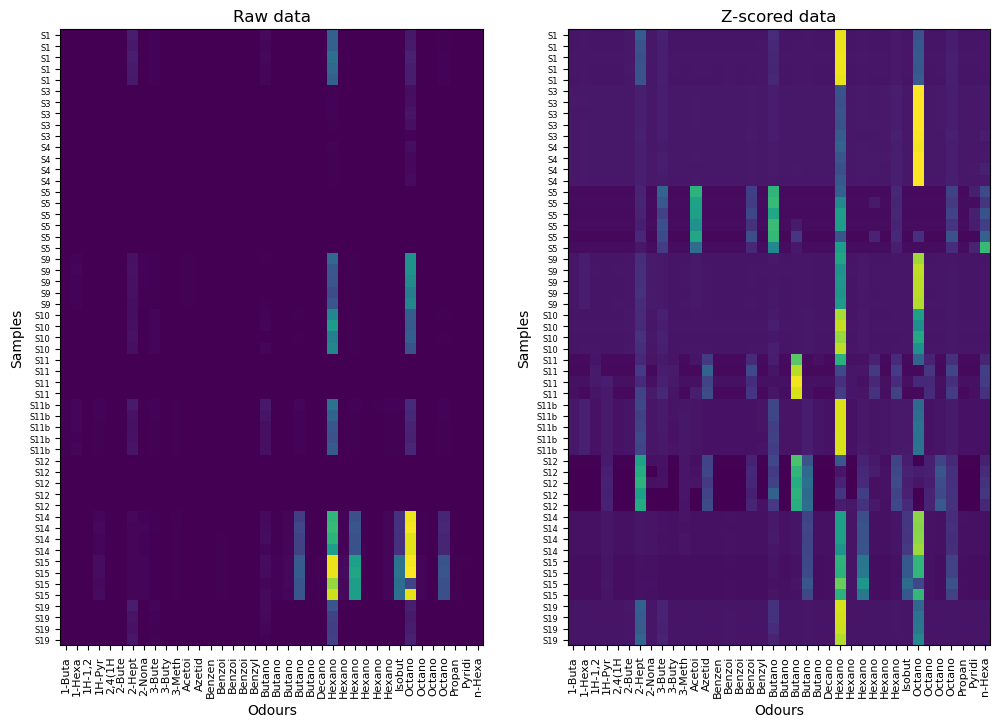

In [160]:
fig, ax = subplots(nrows=1, ncols=2, figsize=(12,8))
ax[0].matshow(tidy[odour_cols], aspect='auto', cmap='viridis'); ax[0].set_title("Raw data"); ax[0].set_xlabel("Odours"); ax[0].set_ylabel("Samples")
ax[1].matshow(tidy_z[odour_cols], aspect='auto', cmap='viridis'); ax[1].set_title("Z-scored data"); ax[1].set_xlabel("Odours"); ax[1].set_ylabel("Samples")
# put the odour ticks on the bottom and label them
for ax_ in ax:
    ax_.set_xticks(range(len(odour_cols)))
    ax_.set_xticklabels([od[:6] for od in odour_cols], rotation=90, fontsize=8)
    # Put the x ticks on the bottom
    ax_.xaxis.set_ticks_position('bottom')
    ax_.set_yticks(range(len(tidy)))
    ax_.set_yticklabels(tidy['Sample'], fontsize=6)

## PCA

In [140]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)

scores = pca.fit_transform(tidy_z[odour_cols].values)
tidy_z[['PC1', 'PC2', 'PC3']] = scores
ev = pca.explained_variance_ratio_
pcs= pca.components_

### Compute PC scores

In [141]:
# Compute the PC score of each odour
pc_score = np.sum(diag(ev) @ abs(pcs[:3]), axis=0) # Multiply the absolute loadings by the variance explained, then sum across the first 3 PCs

### Plot the PCs, and the PC scores for each odour

[[None, None], [None, None], [None, None], [None, None]]

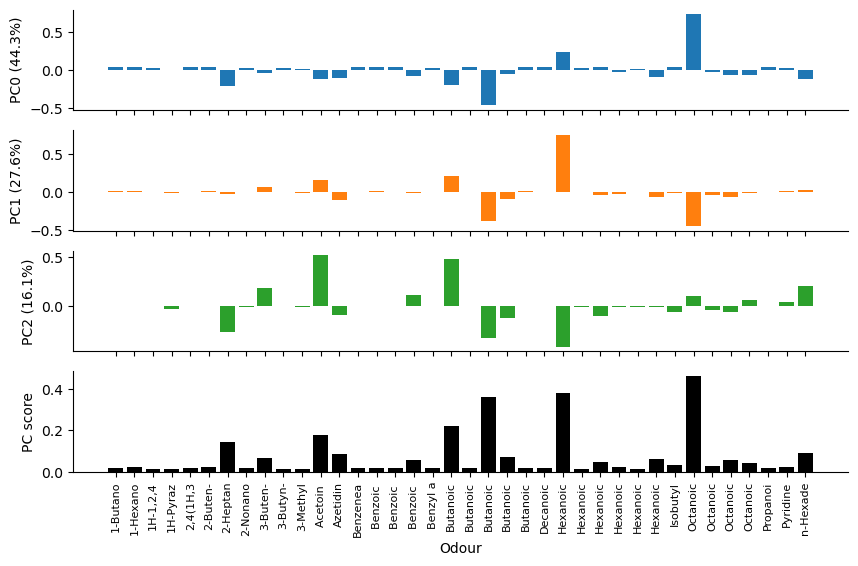

In [161]:
# Plot the principal components
fig,ax = subplots(nrows=4,ncols=1, figsize=(10,6))
spines_off = lambda ax: [ax.spines[side].set_visible(False) for side in ['top', 'right']]
for i, (axi, pc, ev) in enumerate(zip(ax, pca.components_, pca.explained_variance_ratio_)):
    axi.set_xticks(range(len(odour_cols)))
    # Do a bar graph 
    axi.bar(range(len(odour_cols)), pc, label=f'PC{i}', color=f"C{i}")
    axi.set_ylabel(f'PC{i} ({ev:.1%})') 
    axi.set_xticklabels([])
ax[-1].bar(range(len(odour_cols)), pc_score, label='PC score', color="black")
ax[-1].set_xticks(range(len(odour_cols)))
ax[-1].set_xticklabels([od[:8] for od in odour_cols], rotation=90, fontsize=8);
ax[-1].set_ylabel('PC score')
ax[-1].set_xlabel("Odour")
[spines_off(axi) for axi in ax]

## Classification

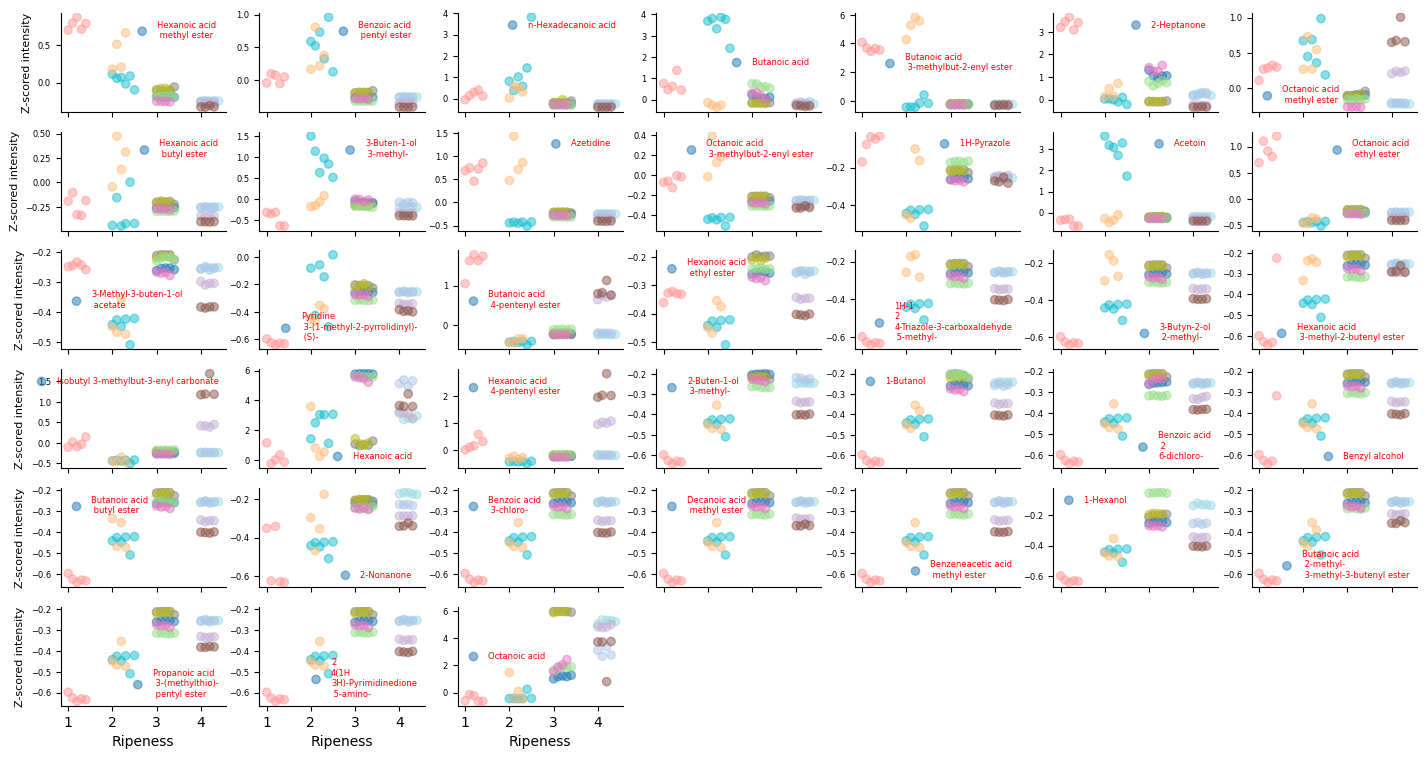

In [231]:
from scipy.stats import spearmanr

# First, let's see how each z-scored odour correlates with ripeness
# Make a square figure full of subplots, each subplot is a scatter plot of one odour vs ripeness
odour_cols = tidy_z.columns.difference(meta_cols)
# Remoev the cols that are PCs
odour_cols = odour_cols[~odour_cols.str.startswith("PC")]

# Compute the pearson correlatio of each odour with ripeness
z_scores = tidy_z[odour_cols].values
y = tidy_z['Ripeness'].values.astype(float)
replicate = tidy_z["Replicate"].values.astype(float)-1
corrs = []
for i in range(z_scores.shape[1]):
    z = z_scores[:, i]
    # Compute the spearman correlation, ignoring NaNs
    r, p = spearmanr(y, z, nan_policy='omit')
    corrs.append(r)
#corrs = np.array([pearsonr(tidy_z['Ripeness'], z_scores[:, i])[0] for i in range(z_scores.shape[1])])

odour_ord = odour_cols[np.argsort(corrs)]

n_rows = 6
n_cols = int(ceil(len(odour_cols) / n_rows))
fig, ax = subplots(nrows=n_rows, ncols=n_cols, figsize=(2.5*n_cols,1.5*n_rows))
codes = pd.Categorical(tidy_z['Sample']).codes
colours = plt.cm.tab20(codes / codes.max())
for i in range(len(odour_cols)):
    odour = odour_ord[i]
    r, c = i//n_cols, i%n_cols
    axi = ax[r, c]
    axi.scatter(y + replicate/10, tidy_z[odour], alpha=0.5, c=colours, label=odour.replace(",", "\n"))
    axi.legend(fontsize=6, frameon=False, labelcolor="red")
    r == n_rows-1 and axi.set_xlabel("Ripeness")
    r < n_rows -1  and axi.set_xticklabels([])
    c == 0 and axi.set_ylabel("Z-scored intensity", fontsize=8) 
    axi.set_xticks(arange(1,5))
    #c != 0 and axi.set_yticklabels([])
    spines_off(axi)
    axi.tick_params(axis='y', labelsize=6)

for i in range(len(odour_cols), n_rows*n_cols):
    fig.delaxes(ax.flatten()[i])

# Run a linear classifier

In [240]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = tidy_z[odour_cols]
y = tidy_z['Ripeness']
groups = tidy_z['Sample']

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-3, 3, 13))   # tries 0.001 to 1000
)

# What you'd report in a paper
group_cv = GroupKFold(n_splits=5)
r2_group = cross_val_score(model, X, y, groups=groups, cv=group_cv, scoring='r2')

# The optimistic upper bound (mixes replicates)
plain_cv = KFold(n_splits=5, shuffle=True, random_state=0)
r2_plain = cross_val_score(model, X, y, cv=plain_cv, scoring='r2')

print(f"R² (grouped, by fruit):    {r2_group.mean():.3f} ± {r2_group.std():.3f}")
print(f"R² (plain k-fold):         {r2_plain.mean():.3f} ± {r2_plain.std():.3f}")
print(f"Gap (replicate leakage):   {r2_plain.mean() - r2_group.mean():.3f}")

R² (grouped, by fruit):    -0.940 ± 2.930
R² (plain k-fold):         0.422 ± 0.716
Gap (replicate leakage):   1.362
